## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## Training

In [2]:
random_state = 42

# Reduced from 1000: at IR=5000 that produced 5M rows and killed RF.
# 200 minority samples is enough to detect degradation across all classifiers.
minority_samples = 200

imbalance_ratios = [10, 100, 500, 1000, 5000]

# Reduced from 5: data is synthetic so variance estimate is cheap at 3 folds.
n_splits = 3

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    # neg_log_loss is negated by sklearn (higher = better); we flip it back in prepare results
    "log_loss": "neg_log_loss",
}

classifiers = {
    "Random Forest": RandomForestClassifier(
        # Reduced from 200: sufficient signal, much faster at high IRs.
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        random_state=random_state,
        n_jobs=-1,
    ),
    # HistGradientBoosting instead of GradientBoostingClassifier: supports n_jobs
    # and uses histogram binning, making it orders of magnitude faster on large datasets.
    "HistGradientBoosting": HistGradientBoostingClassifier(
        min_samples_leaf=1,
        random_state=random_state,
    ),
    "LightGBM": LGBMClassifier(
        min_data_in_leaf=1,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        random_state=random_state,
        verbose=0,
    ),
    # sklearn GradientBoostingClassifier: no n_jobs, slower than HistGBM at high IRs.
    # Included for direct comparison with the histogram-based variant.
    "GBM (sklearn)": GradientBoostingClassifier(
        n_estimators=100,
        random_state=random_state,
    ),
    # Logistic regression needs scaling; wrapped in a pipeline.
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=random_state)),
    ]),
}

results = {name: [] for name in classifiers}

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

for ir in imbalance_ratios:
    majority_samples = minority_samples * ir
    total_samples = majority_samples + minority_samples

    weights = [majority_samples / total_samples, minority_samples / total_samples]

    X, y = make_classification(
        n_samples=total_samples,
        n_features=20,
        n_informative=10,
        n_redundant=5,
        n_repeated=0,
        n_classes=2,
        weights=weights,
        flip_y=0,
        class_sep=0.7,
        random_state=random_state,
    )

    for name, clf in classifiers.items():
        scores = cross_validate(clf, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        results[name].append(scores)
        print(
            f"IR {ir:4d}:1 | {name:25s} | "
            f"ROC-AUC = {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}"
        )


IR   10:1 | Random Forest             | ROC-AUC = 0.9246 ± 0.0313
IR   10:1 | XGBoost                   | ROC-AUC = 0.9490 ± 0.0123
IR   10:1 | HistGradientBoosting      | ROC-AUC = 0.9516 ± 0.0143


/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


IR   10:1 | LightGBM                  | ROC-AUC = 0.9510 ± 0.0152
IR   10:1 | CatBoost                  | ROC-AUC = 0.9706 ± 0.0093
IR   10:1 | GBM (sklearn)             | ROC-AUC = 0.9128 ± 0.0256
IR   10:1 | Logistic Regression       | ROC-AUC = 0.8180 ± 0.0403
IR  100:1 | Random Forest             | ROC-AUC = 0.8906 ± 0.0254
IR  100:1 | XGBoost                   | ROC-AUC = 0.9496 ± 0.0020
IR  100:1 | HistGradientBoosting      | ROC-AUC = 0.9217 ± 0.0020


/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


IR  100:1 | LightGBM                  | ROC-AUC = 0.9580 ± 0.0042
IR  100:1 | CatBoost                  | ROC-AUC = 0.9389 ± 0.0099
IR  100:1 | GBM (sklearn)             | ROC-AUC = 0.8481 ± 0.0106
IR  100:1 | Logistic Regression       | ROC-AUC = 0.8345 ± 0.0191
IR  500:1 | Random Forest             | ROC-AUC = 0.8777 ± 0.0346
IR  500:1 | XGBoost                   | ROC-AUC = 0.9484 ± 0.0091
IR  500:1 | HistGradientBoosting      | ROC-AUC = 0.7281 ± 0.0252


...

IR  500:1 | LightGBM                  | ROC-AUC = 0.7499 ± 0.0803
IR  500:1 | CatBoost                  | ROC-AUC = 0.9458 ± 0.0104
IR  500:1 | GBM (sklearn)             | ROC-AUC = 0.8361 ± 0.0264
IR  500:1 | Logistic Regression       | ROC-AUC = 0.7992 ± 0.0469
IR 1000:1 | Random Forest             | ROC-AUC = 0.8037 ± 0.0552
IR 1000:1 | XGBoost                   | ROC-AUC = 0.9420 ± 0.0183
IR 1000:1 | HistGradientBoosting      | ROC-AUC = 0.4937 ± 0.0436


/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


IR 1000:1 | LightGBM                  | ROC-AUC = 0.4771 ± 0.0165
IR 1000:1 | CatBoost                  | ROC-AUC = 0.9369 ± 0.0171
IR 1000:1 | GBM (sklearn)             | ROC-AUC = 0.7525 ± 0.0598
IR 1000:1 | Logistic Regression       | ROC-AUC = 0.7207 ± 0.0887
IR 5000:1 | Random Forest             | ROC-AUC = 0.7549 ± 0.0425
IR 5000:1 | XGBoost                   | ROC-AUC = 0.9468 ± 0.0162
IR 5000:1 | HistGradientBoosting      | ROC-AUC = 0.4657 ± 0.0698


/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


IR 5000:1 | LightGBM                  | ROC-AUC = 0.4349 ± 0.0671
IR 5000:1 | CatBoost                  | ROC-AUC = 0.9420 ± 0.0203
IR 5000:1 | GBM (sklearn)             | ROC-AUC = 0.7638 ± 0.0547
IR 5000:1 | Logistic Regression       | ROC-AUC = 0.7834 ± 0.0398


## Prepare results

In [17]:
GROUP_1 = ["XGBoost", "Random Forest", "HistGradientBoosting"]
GROUP_2 = ["CatBoost", "GBM (sklearn)", "LightGBM", "Logistic Regression"]

def plot_metric(metric, ylabel, title):
    marker_cycle = ["o", "s", "^", "D", "v", "P"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, group in zip(axes, [GROUP_1, GROUP_2]):
        for name, marker in zip(group, marker_cycle):
            clf_stats = stats[name]
            means = np.array(clf_stats[metric]["mean"])
            stds = np.array(clf_stats[metric]["std"])
            line, = ax.plot(imbalance_ratios, means, marker=marker, label=name)
            ax.fill_between(
                imbalance_ratios, means - stds, means + stds,
                alpha=0.2, color=line.get_color(),
            )
        ax.set_xscale("log")
        ax.set_xticks(imbalance_ratios)
        ax.set_xticklabels(imbalance_ratios)
        ax.set_xlabel("Imbalance Ratio (Majority : Minority)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle(title, y=1.02)
    axes[0].set_title("Tree ensembles (fast)")
    axes[1].set_title("Other models")
    plt.tight_layout()
    plt.show()

## Plot ROC-AUC

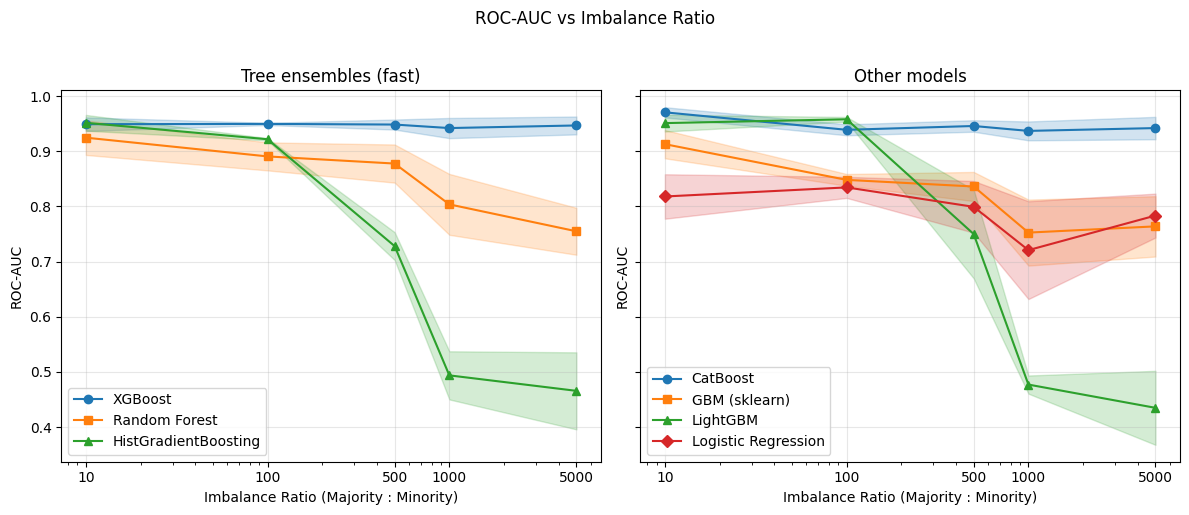

In [18]:
plot_metric("roc_auc", "ROC-AUC", "ROC-AUC vs Imbalance Ratio")

## Plot Average Precision

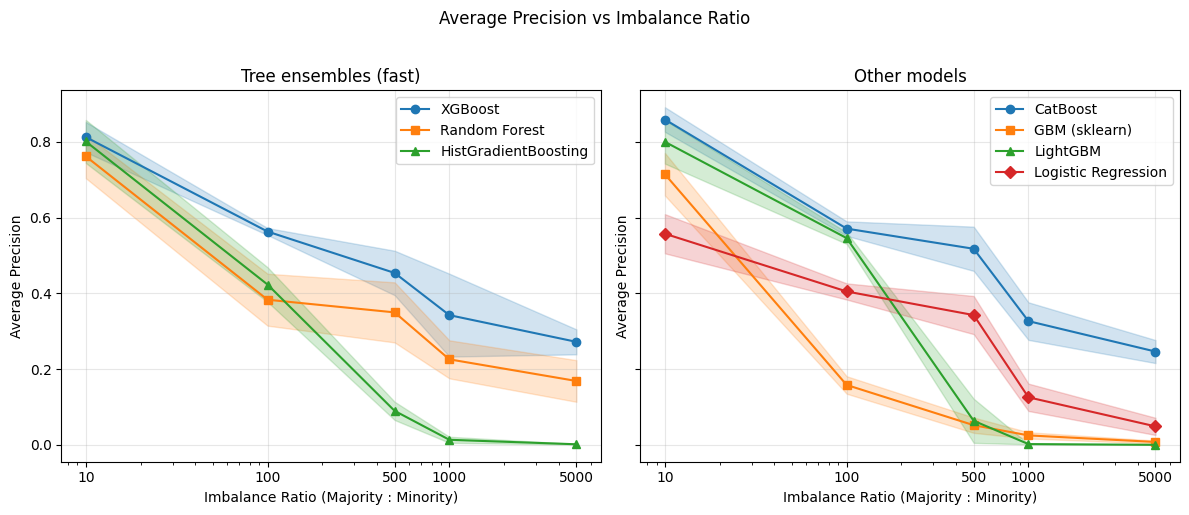

In [19]:
plot_metric("average_precision", "Average Precision", "Average Precision vs Imbalance Ratio")

## Plot Log Loss

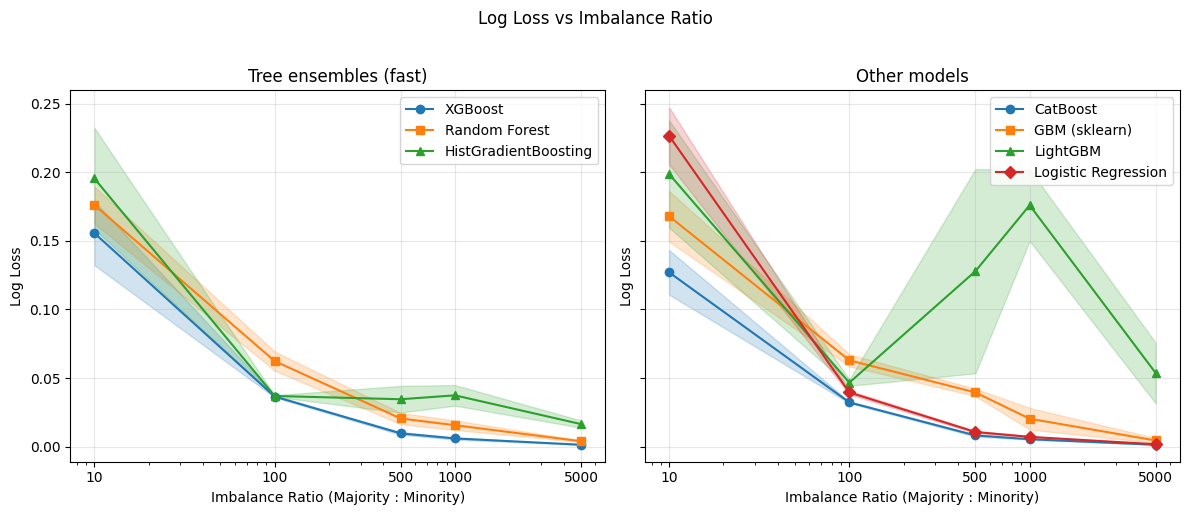

In [20]:
plot_metric("log_loss", "Log Loss", "Log Loss vs Imbalance Ratio")

In [21]:
1/5000, 1/1000

(0.0002, 0.001)